#Pandas para Ciencia de Datos II / Proyecto I – Parte III (Core)
#Análisis y Predicción de Ventas en una Tienda de Retail (Core)
##Parte III: Transformación y Análisis Avanzado de Datos con Pandas

En esta tercera parte del proyecto, continuaremos trabajando con el dataset de ventas que utilizamos en la Parte II. En esta fase, aplicaremos técnicas avanzadas de transformación y análisis de datos utilizando las nuevas habilidades adquiridas en Pandas, tales como agrupaciones complejas y el uso del método apply. Nos enfocaremos en extraer insights más profundos y preparar los datos para futuros análisis y modelos predictivos.


###Instrucciones

1.  Transformación de Datos
* Crea nuevas columnas: Basándonos en los datos existentes, crea nuevas columnas que sean útiles para el análisis. Por ejemplo, calcula el ingreso total por venta y normaliza las ventas.
* Clasifica los datos: Crea una columna que clasifique las ventas en categorías significativas (e.g., ‘Alta’, ‘Media’, ‘Baja’).
2.  Agrupación y Agregación
* Agrupación por múltiples columnas: Realiza agrupaciones por categorías como producto y tienda, producto y mes, etc.
* Aplicar funciones de agregación: Utiliza funciones como sum, mean, count, min, max, std, y var para obtener estadísticas descriptivas de cada grupo.
3.  Análisis Personalizado con apply
* Función personalizada: Aplica funciones personalizadas para realizar análisis específicos que no se pueden lograr con las funciones de agregación estándar.
* Ejemplo de uso avanzado: Calcula la desviación de cada venta respecto a la media de su grupo.
4.  Documentación
* Comentarios claros: Documenta claramente cada paso del análisis, explicando qué se hizo y por qué se hizo.
* Código legible: Asegúrate de que el código sea legible y esté bien comentado.


In [59]:
import pandas as pd

print(f"Versión de pandas: {pd.__version__}")

Versión de pandas: 2.2.2


In [60]:
df = pd.read_csv("retail_sales_dataset.csv")
df.shape

(1000, 9)

In [61]:
df.head(5)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


Visualizacion de los primeros 5 filas del DataFrame

In [62]:
df.tail(5)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


Visualizacion de los ultimos 5 filas del DataFrame

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


Visualizacion la estructura y tipos de datos del DataFrame

In [64]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [65]:
print(df.dtypes)

Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object


se logra visualizar una incongrucia relacionada con los datos de la columna "Transaction ID" ya que los datos son del tipo int64 siendo que deberian str, con el objetivo que no se generen operaciones matematicas sobre el dato

In [66]:
# Duplicados
n_duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {n_duplicados}")

Filas duplicadas: 0


Se busca identificar elemento duplicados en el DataFrame, no se encuentra elementos duplicados en el DataFrame

In [67]:
# Eliminar duplicados (mantiene la primera ocurrencia)
df_drop = df.drop_duplicates()
print(f"Shape Antes de drop_duplicates: {df.shape}")
print(f"Shape después de drop_duplicates: {df_drop.shape}")

Shape Antes de drop_duplicates: (1000, 9)
Shape después de drop_duplicates: (1000, 9)


Este bloque ejecuta las funciones para la eliminacion de los elementos duplicados, en este caso la la dimension del DataFrame no se altera ya que como se indico previamente no hay elementos duplicados.

In [68]:
# nulos
nulos = df.isnull().sum()
print("Nulos por columna:")
print(nulos)

Nulos por columna:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


Se busca identificar datos NaN en el DataFrame, no se encuentra datos NaNs en el DataFrame

In [69]:
df.head(2)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000


In [70]:
# Convertir la columna Date a formato datetime
df['Date'] = pd.to_datetime(df['Date'])
# Extraer el nombre del mes
df['Month'] = df['Date'].dt.month_name()
df.head(2)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,November
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,February


Este Bloque de codigo convierte los dato de la columna "Date" a formato datetime, para luego extraer el mes de la compra.

In [71]:
# Extraer el trimestre (devuelve 1, 2, 3 o 4)
df['Quarter'] = df['Date'].dt.quarter
df.head(2)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Quarter
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,November,4
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,February,1


se crea una nueva columna "Quarter" con el trimestre de la compra

In [72]:
max_value = df['Total Amount'].max()
min_value = df['Total Amount'].min()
df['Total_Amount_norm'] = df['Total Amount'].apply(lambda x: (x - min_value) / (max_value - min_value))
df.head(5)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Quarter,Total_Amount_norm
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,November,4,0.063291
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,February,1,0.493671
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,January,1,0.002532
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,May,2,0.240506
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,May,2,0.037975


se crea la columna "Total_Amount_norm" el cual continen el valor de la normalizacion del dato de la columna "Total Amount", esto ya que hay compras muy altas y muy bajas que puede generar outliers que afecten en un futuro a los modelos

In [73]:
df['purchase_level'] = df['Total Amount'].apply(lambda x: 'Low' if x <= 258 else ('Medium' if x <= 1317 else 'High'))
df.head(5)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Quarter,Total_Amount_norm,purchase_level
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,November,4,0.063291,Low
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,February,1,0.493671,Medium
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,January,1,0.002532,Low
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,May,2,0.240506,Medium
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,May,2,0.037975,Low


Se crea la columna "purchase_level" para categorizar el nivel de las ventas, las categorias son:

*   total de la venta menor o igual 258, su nivel es Low "bajo"
*   total de la venta menor o igual 1317, su nivel es Medium "Medio"
*   total de la venta mayor 1317, su nivel es High "Alto"



In [74]:
insight_1 = df.groupby(['Month', 'Product Category'])['Total Amount'].mean()
print(insight_1)

Month      Product Category
April      Beauty              410.517241
           Clothing            387.222222
           Electronics         382.142857
August     Beauty              407.916667
           Clothing            389.218750
           Electronics         387.236842
December   Beauty              496.000000
           Clothing            464.230769
           Electronics         505.500000
February   Beauty              539.807692
           Clothing            441.212121
           Electronics         594.807692
January    Beauty              535.769231
           Clothing            504.807692
           Electronics         381.730769
July       Beauty              595.925926
           Clothing            434.210526
           Electronics         427.884615
June       Beauty              439.800000
           Clothing            363.214286
           Electronics         647.916667
March      Beauty              502.142857
           Clothing            396.447368
      

Este bloque de codigo calcula la media de las ventas por categoria de producto y mes de la venta.

In [75]:
insight_2 = df.groupby('Gender')['Total Amount'].agg(['min', 'max', 'mean', 'count',  'std', 'var'])
print(insight_2)

        min   max        mean  count         std            var
Gender                                                         
Female   25  2000  456.549020    510  554.299371  307247.792288
Male     25  2000  455.428571    490  566.433809  320847.259714


Este bloque de codigo genera estadisticas sobre el total de las ventas por genero

In [76]:
df['Tax_Amount'] = df['Total Amount'].apply(lambda x: x * 0.19)
df.head(5)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Quarter,Total_Amount_norm,purchase_level,Tax_Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,November,4,0.063291,Low,28.5
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,February,1,0.493671,Medium,190.0
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,January,1,0.002532,Low,5.7
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,May,2,0.240506,Medium,95.0
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,May,2,0.037975,Low,19.0


Este bloque de codigo genera la columna "Tax_Amount", en la cual se calcula los impuestos asociados al total de la compra

In [77]:
df['category_mean'] = df.groupby('Product Category')['Total Amount'].transform('mean')

df['deviation_from_mean'] = df['Total Amount'] - df['category_mean']

print(df[['Product Category', 'Total Amount', 'category_mean', 'deviation_from_mean']])

    Product Category  Total Amount  category_mean  deviation_from_mean
0             Beauty           150     467.475570          -317.475570
1           Clothing          1000     443.247863           556.752137
2        Electronics            30     458.786550          -428.786550
3           Clothing           500     443.247863            56.752137
4             Beauty           100     467.475570          -367.475570
..               ...           ...            ...                  ...
995         Clothing            50     443.247863          -393.247863
996           Beauty            90     467.475570          -377.475570
997           Beauty           100     467.475570          -367.475570
998      Electronics           150     458.786550          -308.786550
999      Electronics           120     458.786550          -338.786550

[1000 rows x 4 columns]


Este bloque de codigo calcula la desviación de cada venta respecto a la media de su grupo.

In [78]:
#Pandas para Ciencia de Datos II / Proyecto I – Parte III

'''
Análisis y Predicción de Ventas en una Tienda de Retail (Core)
Parte III: Transformación y Análisis Avanzado de Datos con Pandas

Author: Wilson Navarrete.
Date: 08/05/2026.
Calama - Chile.
'''

'\nAnálisis y Predicción de Ventas en una Tienda de Retail (Core)\nParte III: Transformación y Análisis Avanzado de Datos con Pandas\n\nAuthor: Wilson Navarrete.\nDate: 08/05/2026.\nCalama - Chile.\n'

#Visualización para ciencia de datos / Proyecto I – Parte IV (Core)

#Proyecto I – Parte IV (Core)
##Análisis y Predicción de Ventas en una Tienda de Retail

###Parte IV: Análisis Exploratorio de Datos (EDA) y Visualización

En esta cuarta parte del proyecto, aplicaremos técnicas avanzadas de análisis exploratorio de datos (EDA) y visualización para comprender mejor el conjunto de datos de ventas de la tienda de retail. Utilizaremos Python, Pandas y Matplotlib para explorar y visualizar los datos, identificar patrones y tendencias, y preparar los datos para un análisis más profundo.

###Instrucciones

1. Continuar desde la Parte III
* Asegúrate de tener el repositorio de GitHub clonado localmente y el dataset ya limpiado y preparado desde la Parte III.
2. Análisis Descriptivo y Visualización
* Calcula estadísticas descriptivas básicas para comprender mejor las características de los datos.
* Utiliza histogramas y boxplots para visualizar la distribución de las variables numéricas clave.
* Crea gráficos de líneas para mostrar las tendencias de ventas a lo largo del tiempo.
* Utiliza gráficos de dispersión para analizar la relación entre diferentes variables.
* Combina histogramas y boxplots para visualizar la distribución de las ventas y detectar valores atípicos.
3. Generar un Pull Request en GitHub
* Después de completar el análisis y las visualizaciones, sube los cambios a una nueva rama en tu repositorio de GitHub y genera un Pull Request (PR) para revisión.

### Informacion del DataFrame

In [79]:
# Imprime la lista de nombres de columnas del DataFrame 'df', que corresponden
# a los encabezados del archivo CSV previamente cargado.
# Indicando la cantida de registros totales del DataFrame, la cantidad de registro
# distintos a nulo y el tipo de variable

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Transaction ID       1000 non-null   int64         
 1   Date                 1000 non-null   datetime64[ns]
 2   Customer ID          1000 non-null   object        
 3   Gender               1000 non-null   object        
 4   Age                  1000 non-null   int64         
 5   Product Category     1000 non-null   object        
 6   Quantity             1000 non-null   int64         
 7   Price per Unit       1000 non-null   int64         
 8   Total Amount         1000 non-null   int64         
 9   Month                1000 non-null   object        
 10  Quarter              1000 non-null   int32         
 11  Total_Amount_norm    1000 non-null   float64       
 12  purchase_level       1000 non-null   object        
 13  Tax_Amount           1000 non-null

In [80]:
# Imprime un mensaje indicando que se mostrarán los nombres de las columnas
print("Nombre de las Columnas:")
# Imprime los nombres de las columnas del DataFrame 'df'
print(df.columns)

Nombre de las Columnas:
Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount',
       'Month', 'Quarter', 'Total_Amount_norm', 'purchase_level', 'Tax_Amount',
       'category_mean', 'deviation_from_mean'],
      dtype='object')


### Estadisticas Descriptivas

In [81]:
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount,Quarter,Total_Amount_norm,Tax_Amount,category_mean,deviation_from_mean
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1.000000e+03
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000,2.525000,0.218228,86.64000,456.000000,3.637979e-14
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000,1.000000,0.000000,4.75000,443.247863,-4.424756e+02
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000,2.000000,0.017722,11.40000,443.247863,-3.924756e+02
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000,2.000000,0.055696,25.65000,458.786550,-3.203617e+02
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000,4.000000,0.443038,171.00000,467.475570,4.325244e+02
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000,4.000000,1.000000,380.00000,467.475570,1.556752e+03
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632,1.119208,0.283543,106.39955,10.013133,5.599081e+02


### Visualización de cabecera y cola del DataFrame

In [82]:
# Muestra las primeras 5 filas del DataFrame 'df' para verificar los cambios en los
# nombres de las columnas
df.head(10)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Quarter,Total_Amount_norm,purchase_level,Tax_Amount,category_mean,deviation_from_mean
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,November,4,0.063291,Low,28.5,467.475570,-317.475570
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,February,1,0.493671,Medium,190.0,443.247863,556.752137
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,January,1,0.002532,Low,5.7,458.786550,-428.786550
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,May,2,0.240506,Medium,95.0,443.247863,56.752137
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,May,2,0.037975,Low,19.0,467.475570,-367.475570
5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30,April,2,0.002532,Low,5.7,467.475570,-437.475570
6,7,2023-03-13,CUST007,Male,46,Clothing,2,25,50,March,1,0.012658,Low,9.5,443.247863,-393.247863
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100,February,1,0.037975,Low,19.0,458.786550,-358.786550
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600,December,4,0.291139,Medium,114.0,458.786550,141.213450
9,10,2023-10-07,CUST010,Female,52,Clothing,4,50,200,October,4,0.088608,Low,38.0,443.247863,-243.247863


In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

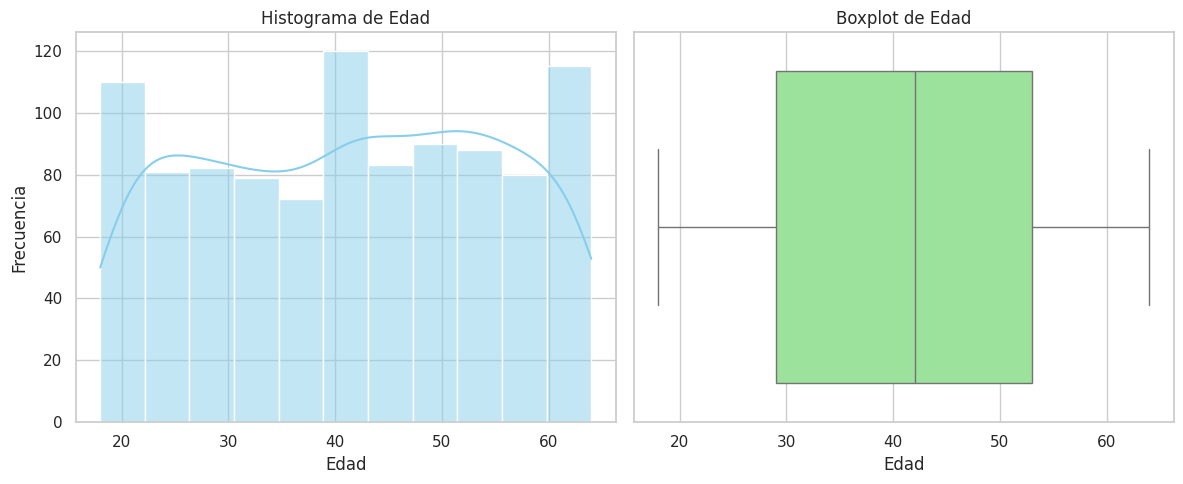

In [84]:
# Configurar el estilo
sns.set_theme(style="whitegrid")

# Crear una figura con dos subgráficos
plt.figure(figsize=(12, 5))

# Subgráfico 1: Histograma
plt.subplot(1, 2, 1)
sns.histplot(df['Age'], kde=True, color='skyblue')
plt.title('Histograma de Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

# Subgráfico 2: Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df['Age'], color='lightgreen')
plt.title('Boxplot de Edad')
plt.xlabel('Edad')

plt.tight_layout()

plt.savefig(
    'Histograma y Boxplot de Edad.png',
    format='png',
    dpi=300,              # Alta resolución (ideal para impresión o pantallas 4K)
    bbox_inches='tight',  # Elimina márgenes blancos sobrantes alrededor del gráfico
    transparent=False     # Cambia a True si necesitas que el fondo sea transparente
)
plt.show()

* El histograma nos permite visualizar como se agrupan los clientes por rango de edad, la distribucion  es bastante uniforme, lo que se traducen en que la el espectro de clientes es amplio en edad.
* El boxplot nos permite visualizar que no hay clientes con edades anomalas. Asi tambien se puede visualizar que la mediana en la edad de los clientes esta aproximadamente en los 43 años.

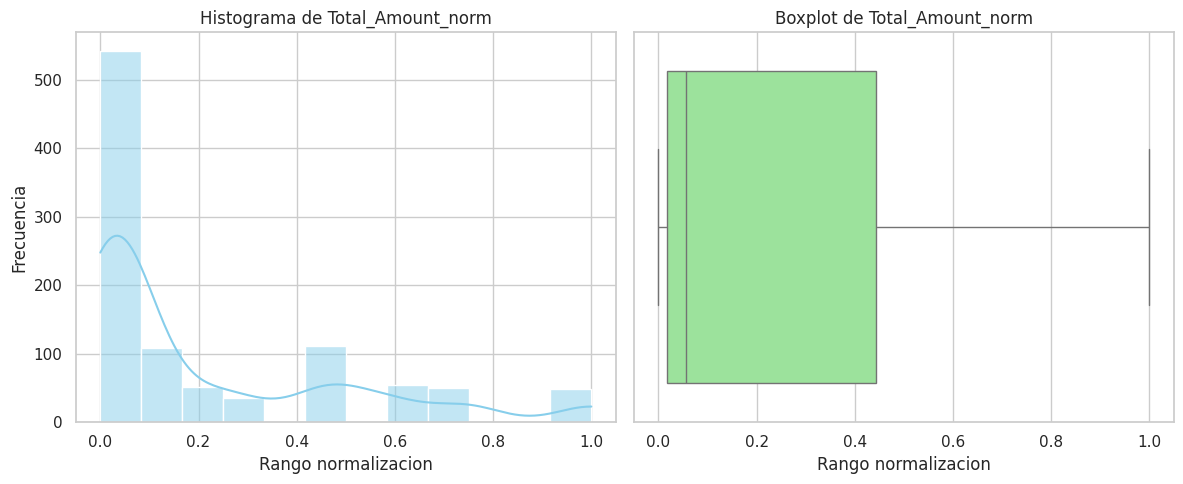

In [85]:
# Configurar el estilo
sns.set_theme(style="whitegrid")

# Crear una figura con dos subgráficos
plt.figure(figsize=(12, 5))

# Subgráfico 1: Histograma
plt.subplot(1, 2, 1)
sns.histplot(df['Total_Amount_norm'], kde=True, color='skyblue')
plt.title('Histograma de Total_Amount_norm')
plt.xlabel('Rango normalizacion')
plt.ylabel('Frecuencia')

# Subgráfico 2: Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df['Total_Amount_norm'], color='lightgreen')
plt.title('Boxplot de Total_Amount_norm')
plt.xlabel('Rango normalizacion')

plt.tight_layout()

plt.savefig(
    'Histograma de Total_Amount_norm.png',
    format='png',
    dpi=300,              # Alta resolución (ideal para impresión o pantallas 4K)
    bbox_inches='tight',  # Elimina márgenes blancos sobrantes alrededor del gráfico
    transparent=False     # Cambia a True si necesitas que el fondo sea transparente
)

plt.show()

* el boxplot nos permite visualizar que  todas las normalizaciones generadas sobre el monto  total de las compras se encuentra entre el rango correspondiente (0 - 1), lo cual concluye que no hay monto anomalos.
* El histograma muestra que una gran cantida de montos totales de compras se encuentra normalizado en el rango de 0.0 - 0.1, de lo cual se puede inferir que la mayor parte de la compras son por monto bajos.

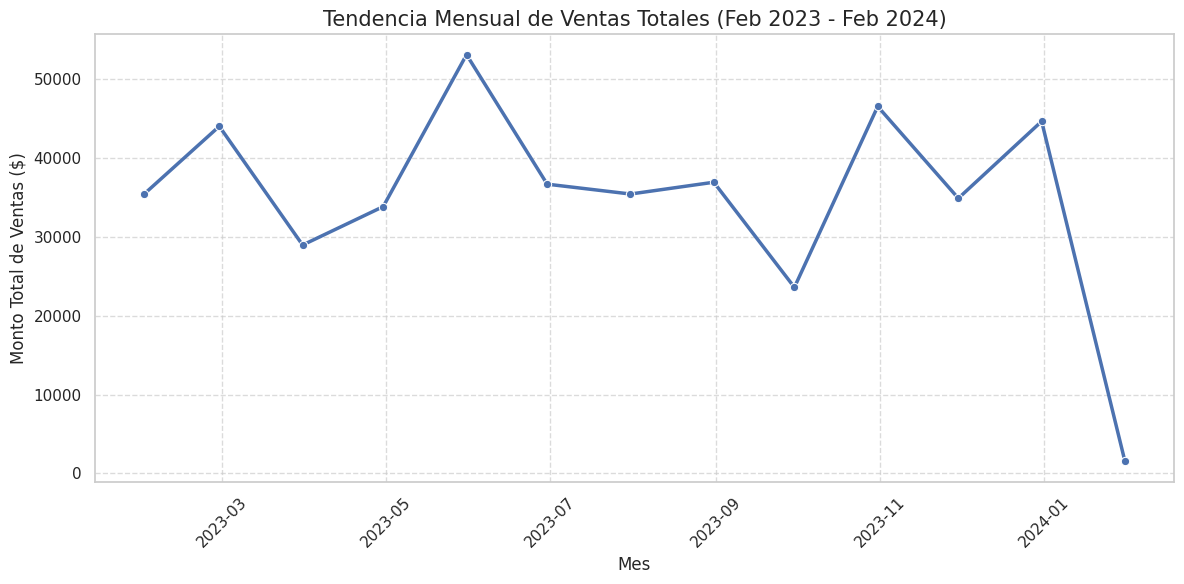

In [86]:
# Agrupar por mes para suavizar la tendencia y verla con claridad
# Sumamos el 'Total Amount' para cada mes
ventas_mensuales = df.resample('ME', on='Date')['Total Amount'].sum()

'''
df.resample() en Pandas es un método esencial para el remuestreo de series temporales, permitiendo cambiar la frecuencia de los datos (por ejemplo, convertir datos diarios a mensuales) y agruparlos para realizar cálculos. Es similar a groupby, pero especializado para índices de tiempo, permitiendo Downsampling (reducir frecuencia
'''
# Crear el gráfico de líneas
plt.figure(figsize=(12, 6))
sns.lineplot(x=ventas_mensuales.index, y=ventas_mensuales.values, marker='o', color='b', linewidth=2.5)

# Configuración de etiquetas y título
plt.title('Tendencia Mensual de Ventas Totales (Feb 2023 - Feb 2024)', fontsize=15)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Monto Total de Ventas ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Ajustar el formato de las fechas en el eje X para que sea legible
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    'Tendencia Mensual de Ventas Totales (Feb 2023 - Feb 2024).png',
    format='png',
    dpi=300,              # Alta resolución (ideal para impresión o pantallas 4K)
    bbox_inches='tight',  # Elimina márgenes blancos sobrantes alrededor del gráfico
    transparent=False     # Cambia a True si necesitas que el fondo sea transparente
)

plt.show()

* Al graficar el monto total frente a la fecha, podemos observar como fluctuan los ingresos durante un periodo determinado de tiempo (Feb 2023 - Feb 2024)

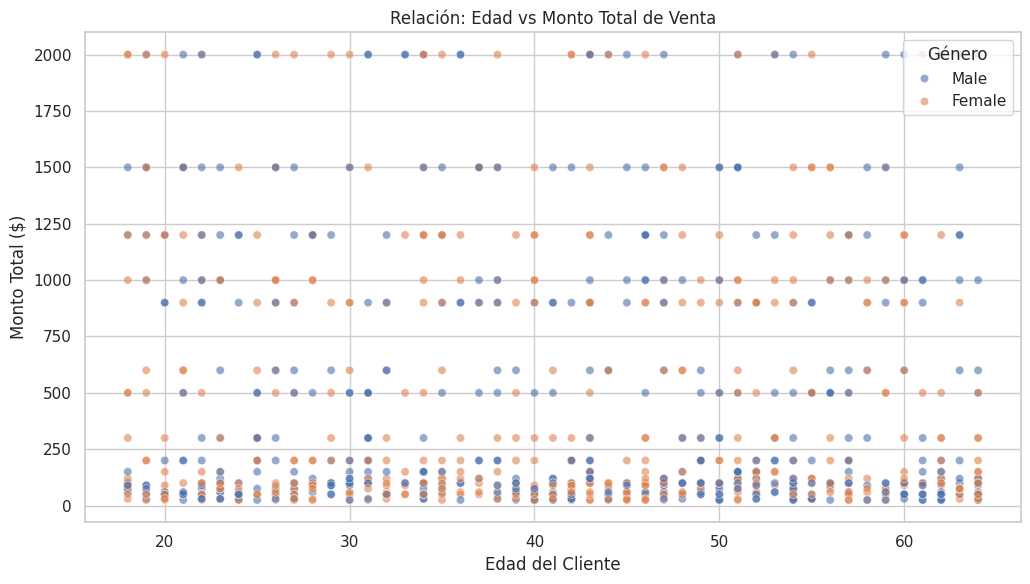

In [87]:
# Configurar el estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 6))

# Gráfico Edad vs Monto Total
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='Age', y='Total Amount', hue='Gender', alpha=0.6)
plt.title('Relación: Edad vs Monto Total de Venta')
plt.xlabel('Edad del Cliente')
plt.ylabel('Monto Total ($)')
plt.legend(title='Género', loc='upper right')

plt.tight_layout()

plt.savefig(
    'Relación Edad vs Monto Total de Venta.png',
    format='png',
    dpi=300,              # Alta resolución (ideal para impresión o pantallas 4K)
    bbox_inches='tight',  # Elimina márgenes blancos sobrantes alrededor del gráfico
    transparent=False     # Cambia a True si necesitas que el fondo sea transparente
)

plt.show()

* No se observa una correlación lineal fuerte. Esto sugiere que el poder adquisitivo o la disposición al gasto en esta tienda no está estrictamente ligada a la edad del cliente.

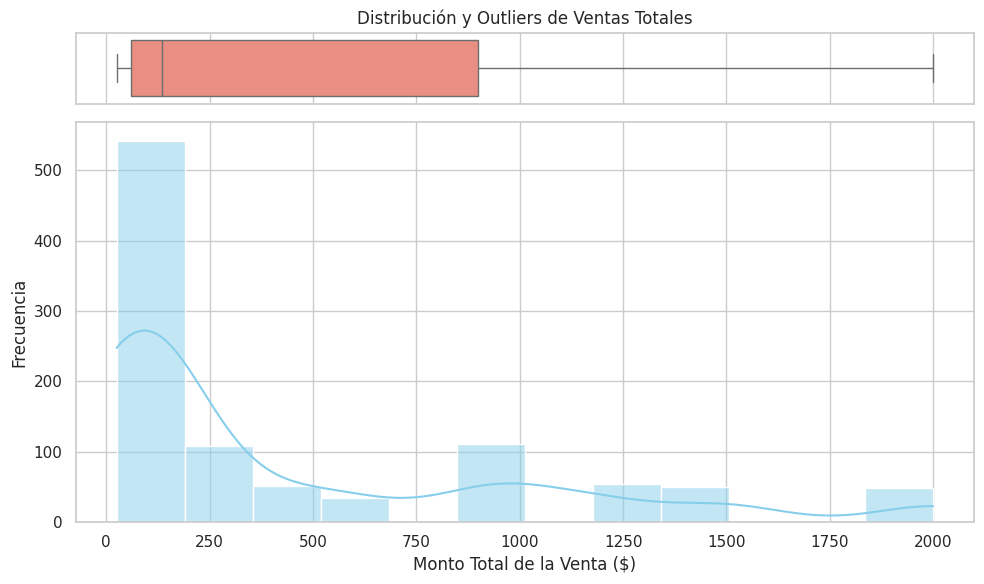

In [88]:
# Crear una figura con dos subplots compartiendo el eje X
# El boxplot ocupará menos espacio (height_ratios)
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(10, 6))

# Crear el Boxplot en la parte superior
sns.boxplot(x=df["Total Amount"], ax=ax_box, color="salmon")
ax_box.set(title='Distribución y Outliers de Ventas Totales', xlabel='') # Quitar etiquetas sobrantes

# Crear el Histograma con KDE (curva de densidad) en la parte inferior
sns.histplot(df["Total Amount"], ax=ax_hist, kde=True, color="skyblue")
ax_hist.set(xlabel='Monto Total de la Venta ($)', ylabel='Frecuencia')

# Ajustar diseño
plt.tight_layout()

plt.savefig(
    'Distribución y Outliers de Ventas Totales.png',
    format='png',
    dpi=300,              # Alta resolución (ideal para impresión o pantallas 4K)
    bbox_inches='tight',  # Elimina márgenes blancos sobrantes alrededor del gráfico
    transparent=False     # Cambia a True si necesitas que el fondo sea transparente
)
plt.show()

* las ventas estan sesgadas hacia la derecha, ya que hay muchas compras de monto pequeño y pocas compras de montos altos.
* un valor atipico aqui podria ser un compra de $2000. aunque es unmonto alto esta dentro de los limites descartando que se un monto anomalo.

In [89]:
#Visualización para ciencia de datos / Proyecto I – Parte IV (Core)

'''
Análisis y Predicción de Ventas en una Tienda de Retail
Parte IV: Análisis Exploratorio de Datos (EDA) y Visualización

Author: Wilson Navarrete.
Date: 15/05/2026.
Calama - Chile.
'''

'\nAnálisis y Predicción de Ventas en una Tienda de Retail\nParte IV: Análisis Exploratorio de Datos (EDA) y Visualización\n\nAuthor: Wilson Navarrete.\nDate: 15/05/2026.\nCalama - Chile.\n'

##Visualización para ciencia de datos / Proyecto 1 – Parte V (Core)

## Proyecto 1 – Parte V (Core)
### Análisis y Predicción de Ventas en una Tienda de Retail

##Parte V: Exploración y Visualización de Datos Avanzada

En esta quinta parte del proyecto, vamos a expandir nuestro análisis exploratorio de datos (EDA) y visualización utilizando técnicas avanzadas. Aplicaremos todo lo que hemos aprendido hasta ahora, incluyendo cuadrículas, leyendas, anotaciones, flechas, y subplots, para obtener una comprensión más profunda de nuestro conjunto de datos de ventas.

##Instrucciones

1. Continuar desde la Parte IV
* Asegúrate de tener el DataFrame df ya cargado y preparado desde la Parte IV.
2. Exploración de Datos Avanzada
* Realiza un análisis de correlación y crea un mapa de calor para visualizar las relaciones entre las variables.
* Crea subplots para comparar diferentes variables clave.
* Añade cuadrículas, leyendas, anotaciones y flechas a tus gráficos para mejorar la claridad y la información.
3. Generar un Tag en GitHub y Realizar una Presentación
*Generar un Tag en GitHub: Después de completar el análisis y las visualizaciones, sube los cambios a una nueva rama en tu repositorio de GitHub, genera un Pull Request (PR) para revisión y finalmente crea un tag para esta versión del proyecto.
* Realizar una Presentación: Prepara una presentación en slides que resuma tu análisis y  visualizaciones. La presentación debe incluir:

*       Introducción y objetivos del proyecto.
*       Descripción del conjunto de datos.
*       Principales análisis y hallazgos.
*       Visualizaciones clave con explicación.
*       Conclusiones y recomendaciones.

Utiliza herramientas como PowerPoint, Google Slides o cualquier otra aplicación de presentación.

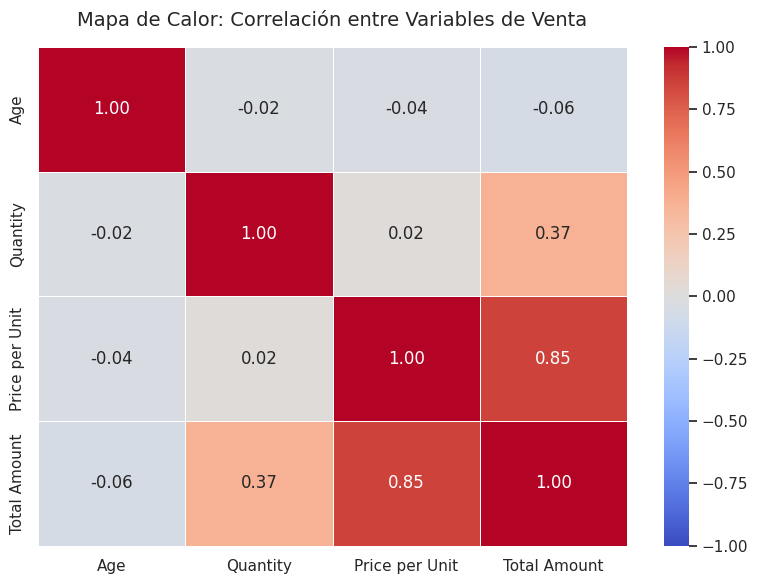

In [90]:
# Seleccionar solo las variables numéricas relevantes para la correlación
variables_numericas = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']]

# Calcular la matriz de correlación de Pearson
matriz_correlacion = variables_numericas.corr()

# Configurar el tamaño de la gráfica
plt.figure(figsize=(8, 6))

# Crear el mapa de calor
sns.heatmap(
    matriz_correlacion,
    annot=True,          # Muestra los valores numéricos dentro de cada celda
    cmap='coolwarm',     # Paleta de colores (azul para negativo, rojo para positivo)
    fmt=".2f",           # Limita a 2 decimales
    linewidths=0.5,      # Añade una línea de separación entre celdas
    vmin=-1, vmax=1      # Establece los límites de la escala de color
)

# Configuración de títulos
plt.title('Mapa de Calor: Correlación entre Variables de Venta', fontsize=14, pad=15)
plt.tight_layout()

plt.savefig(
    'Mapa de Calor, Correlación entre Variables de Venta.png',
    format='png',
    dpi=300,              # Alta resolución (ideal para impresión o pantallas 4K)
    bbox_inches='tight',  # Elimina márgenes blancos sobrantes alrededor del gráfico
    transparent=False     # Cambia a True si necesitas que el fondo sea transparente
)

# Mostrar el gráfico
plt.show()

* Total Amount VS Price per Unit, esta correlacion es positiva y fuerte, lo cual le da mayor ratificacion a la logica, a mas alto el precio unitario a mayor el monto total de la compra.
* La edad no tiene relacion con la cantidad de articulos comprados, ni con el precio de estos. Esto confirma estadisticamenete que los habitos estan distribuido uniformemente entre jovenes y adultos.


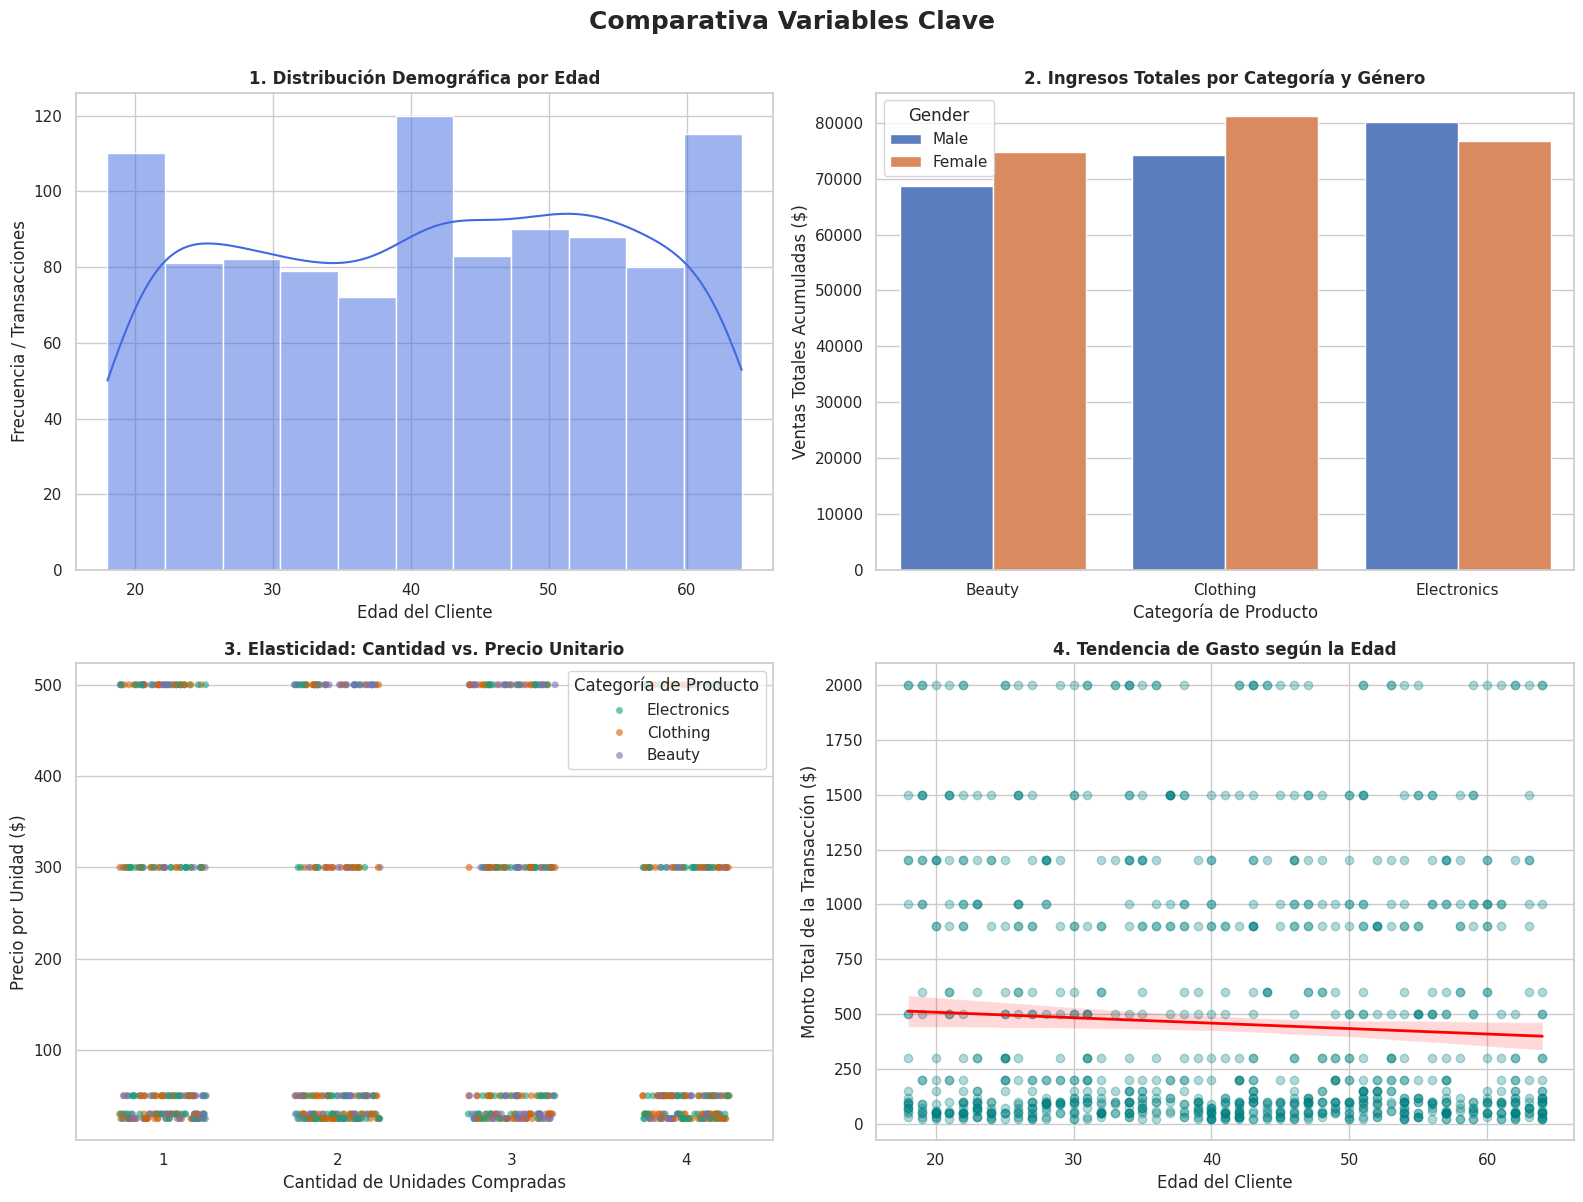

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configurar el estilo general y el tamaño de la matriz de gráficos
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comparativa Variables Clave', fontsize=18, fontweight='bold', y=1)

# --- Subplot [0, 0]: Distribución de Edad ---
sns.histplot(data=df, x='Age', kde=True, color='royalblue', ax=axes[0, 0])
axes[0, 0].set_title('1. Distribución Demográfica por Edad', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Edad del Cliente')
axes[0, 0].set_ylabel('Frecuencia / Transacciones')

# --- Subplot [0, 1]: Ventas Totales por Categoría y Género ---
sns.barplot(data=df, x='Product Category', y='Total Amount', hue='Gender',
            estimator=sum, errorbar=None, palette='muted', ax=axes[0, 1])
axes[0, 1].set_title('2. Ingresos Totales por Categoría y Género', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Categoría de Producto')
axes[0, 1].set_ylabel('Ventas Totales Acumuladas ($)')

# --- Subplot [1, 0]: Relación Precio Unitario vs Cantidad ---
# Usamos jitter (pequeño desplazamiento) para manejar la naturaleza discreta de 'Quantity'
sns.stripplot(data=df, x='Quantity', y='Price per Unit', hue='Product Category',
              jitter=0.25, size=5, alpha=0.6, palette='Dark2', ax=axes[1, 0])
axes[1, 0].set_title('3. Elasticidad: Cantidad vs. Precio Unitario', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Cantidad de Unidades Compradas')
axes[1, 0].set_ylabel('Precio por Unidad ($)')
axes[1, 0].legend(title='Categoría de Producto', loc='upper right') # Fix applied here

# --- Subplot [1, 1]: Edad vs Monto Total con Línea de Tendencia ---
sns.regplot(data=df, x='Age', y='Total Amount', scatter_kws={'alpha':0.3, 'color':'teal'},
            line_kws={'color':'red', 'linewidth':2}, ax=axes[1, 1])
axes[1, 1].set_title('4. Tendencia de Gasto según la Edad', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Edad del Cliente')
axes[1, 1].set_ylabel('Monto Total de la Transacción ($)')

# Optimizar el espacio entre subplots para evitar superposición de etiquetas
plt.tight_layout()

plt.savefig(
    'Comparativa Variables Clave.png',
    format='png',
    dpi=300,              # Alta resolución (ideal para impresión o pantallas 4K)
    bbox_inches='tight',  # Elimina márgenes blancos sobrantes alrededor del gráfico
    transparent=False     # Cambia a True si necesitas que el fondo sea transparente
)


# Mostrar la composición final
plt.show()

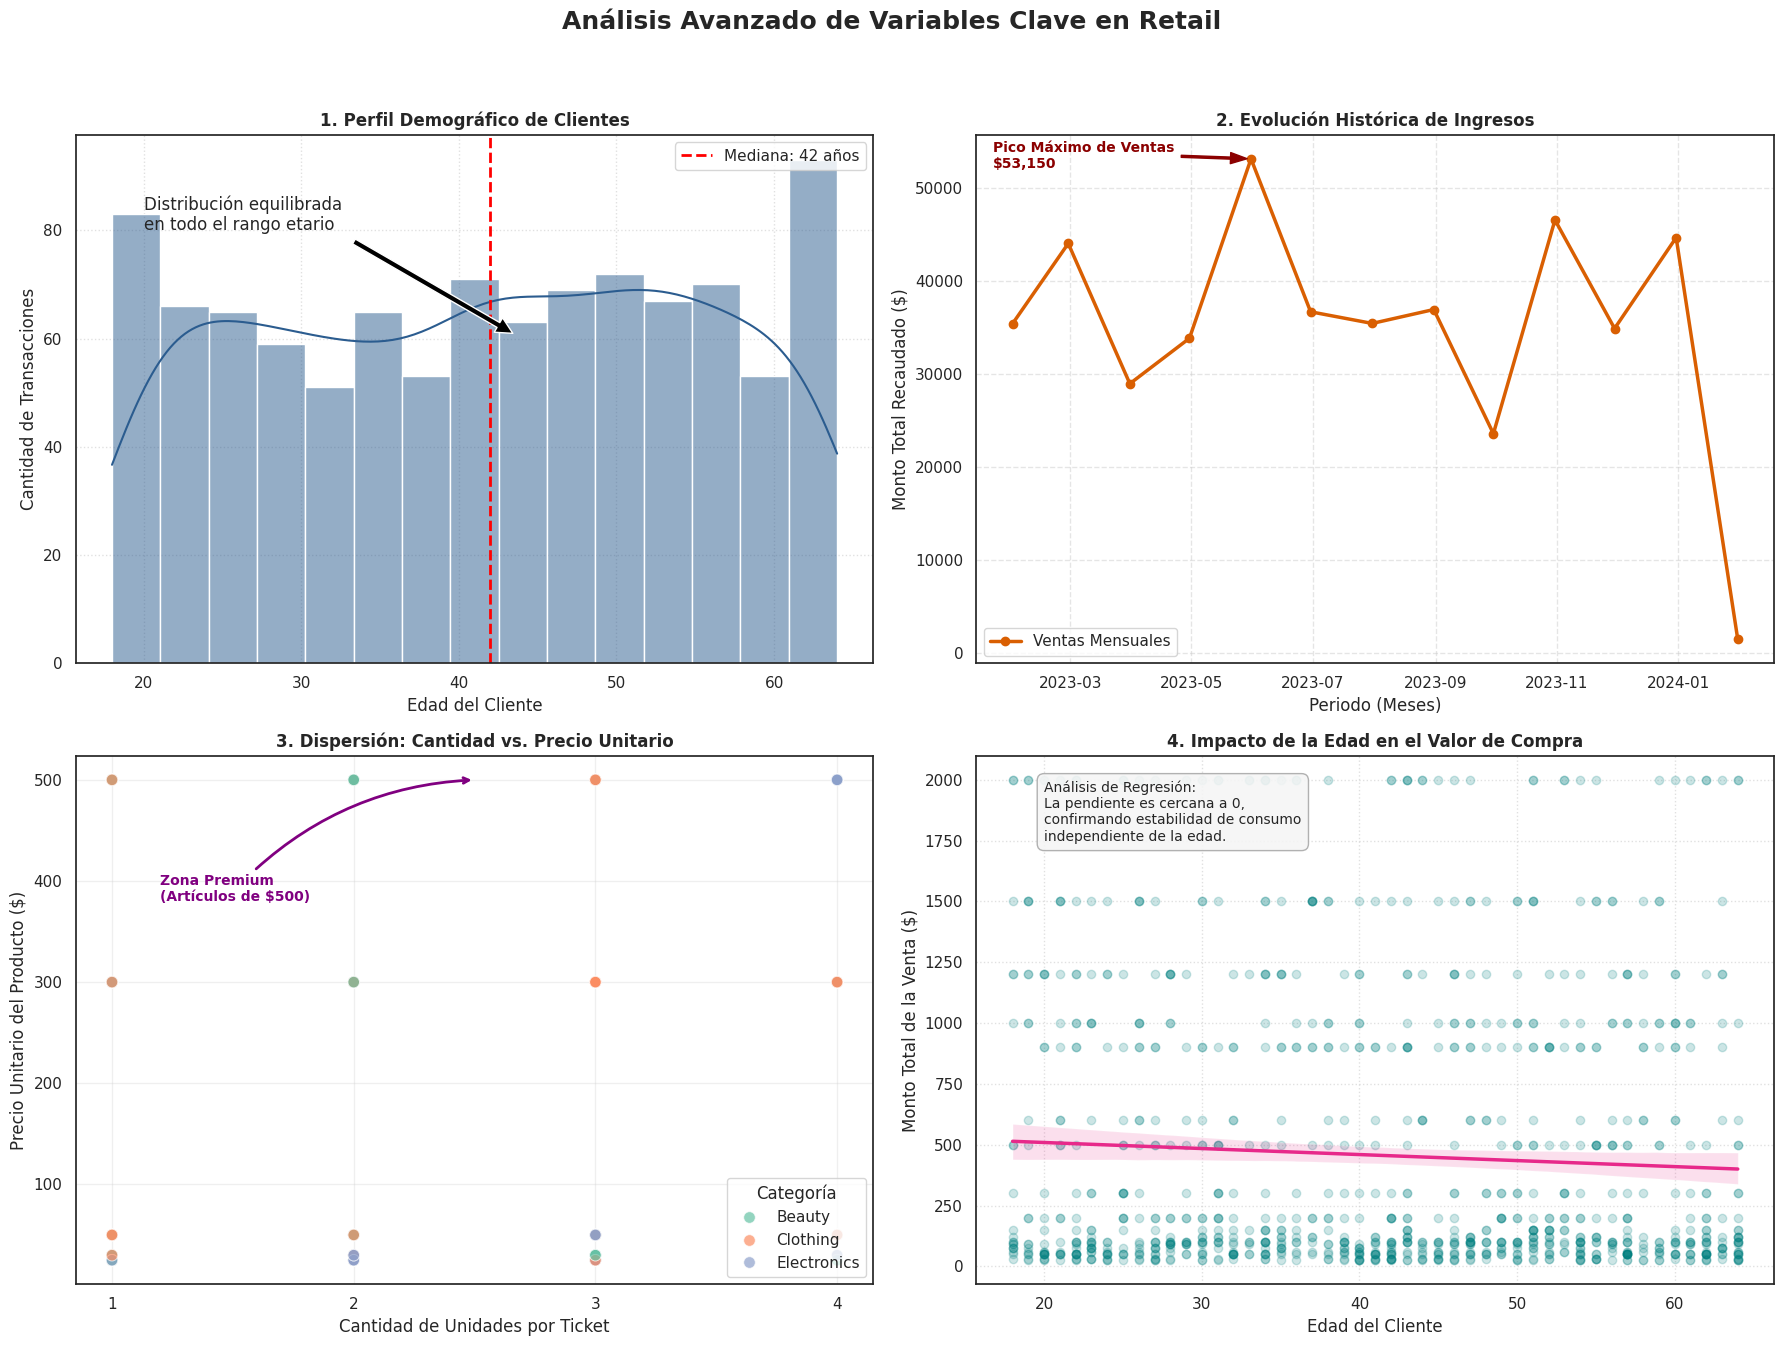

In [92]:
# Calcular métricas clave para las anotaciones
mediana_edad = df['Age'].median()
ventas_mensuales = df.resample('ME', on='Date')['Total Amount'].sum()
mes_max = ventas_mensuales.idxmax()
venta_max = ventas_mensuales.max()

# Configurar la estructura principal de la gráfica (Estilo y Cuadrícula)
sns.set_theme(style="white") # Fondo limpio para resaltar anotaciones
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Análisis Avanzado de Variables Clave en Retail', fontsize=18, fontweight='bold', y=0.96)

# SUBPLOT [0, 0]: DISTRIBUCIÓN DE EDAD
sns.histplot(data=df, x='Age', kde=True, color='#2b5c8f', ax=axes[0, 0], bins=15)
axes[0, 0].axvline(mediana_edad, color='red', linestyle='--', linewidth=2, label=f'Mediana: {int(mediana_edad)} años')
axes[0, 0].set_title('1. Perfil Demográfico de Clientes', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Edad del Cliente')
axes[0, 0].set_ylabel('Cantidad de Transacciones')
axes[0, 0].grid(True, linestyle=':', alpha=0.6)
axes[0, 0].legend(loc='upper right')

# Flecha y anotación en Edad
axes[0, 0].annotate('Distribución equilibrada\nen todo el rango etario',
                    xy=(44, 60), xytext=(20, 80),
                    arrowprops=dict(facecolor='black', shrink=0.05))


# SUBPLOT [0, 1]: TENDENCIA TEMPORAL DE VENTAS
axes[0, 1].plot(ventas_mensuales.index, ventas_mensuales.values, marker='o', color='#d95f02', linewidth=2.5, label='Ventas Mensuales')
axes[0, 1].set_title('2. Evolución Histórica de Ingresos', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Periodo (Meses)')
axes[0, 1].set_ylabel('Monto Total Recaudado ($)')
axes[0, 1].grid(True, linestyle='--', alpha=0.5)
axes[0, 1].legend(loc='lower left')

# Flecha y anotación para el pico máximo de ventas
axes[0, 1].annotate(f'Pico Máximo de Ventas\n${venta_max:,.0f}',
                    xy=(mes_max, venta_max), xytext=(mes_max - pd.Timedelta(days=130),  venta_max - 1000),
                    arrowprops=dict(facecolor='darkred', edgecolor='darkred', shrink=0.05, width=1.5, headwidth=8),
                    fontsize=10, fontweight='bold', color='darkred')


# SUBPLOT [1, 0]: PRECIO UNITARIO VS CANTIDAD
sns.scatterplot(data=df, x='Quantity', y='Price per Unit', hue='Product Category',
                palette='Set2', alpha=0.7, s=70, ax=axes[1, 0])
axes[1, 0].set_title('3. Dispersión: Cantidad vs. Precio Unitario', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Cantidad de Unidades por Ticket')
axes[1, 0].set_ylabel('Precio Unitario del Producto ($)')
axes[1, 0].set_xticks([1, 2, 3, 4]) # Fijar ticks al ser variable discreta
axes[1, 0].grid(True, linestyle='-', alpha=0.3)
axes[1, 0].legend(title='Categoría', loc='lower right')

# Flecha apuntando a productos de alto valor
axes[1, 0].annotate('Zona Premium\n(Artículos de $500)',
                    xy=(2.5, 500), xytext=(1.2, 380),
                    arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=-0.2", color="purple", lw=2),
                    fontsize=10, color='purple', fontweight='bold')



# SUBPLOT [1, 1]: EDAD VS MONTO TOTAL (TENDENCIA)
sns.regplot(data=df, x='Age', y='Total Amount', scatter_kws={'alpha':0.2, 'color':'teal'},
            line_kws={'color':'#e7298a', 'linewidth':2.5}, ax=axes[1, 1])
axes[1, 1].set_title('4. Impacto de la Edad en el Valor de Compra', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Edad del Cliente')
axes[1, 1].set_ylabel('Monto Total de la Venta ($)')
axes[1, 1].grid(True, linestyle=':', alpha=0.6)

# Cuadro de anotación de texto estadístico (Bbox)
axes[1, 1].text(20, 1750, 'Análisis de Regresión:\nLa pendiente es cercana a 0,\nconfirmando estabilidad de consumo\nindependiente de la edad.',
                bbox=dict(facecolor='whitesmoke', alpha=0.9, edgecolor='darkgray', boxstyle='round,pad=0.5'),
                fontsize=10)


# ajustes finales de espaciado y renderizado
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(
    'Análisis Avanzado de Variables Clave en Retail.png',
    format='png',
    dpi=300,              # Alta resolución (ideal para impresión o pantallas 4K)
    bbox_inches='tight',  # Elimina márgenes blancos sobrantes alrededor del gráfico
    transparent=False     # Cambia a True si necesitas que el fondo sea transparente
)

plt.show()